In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../Resources/TF_2_Notebooks_and_Data/DATA/RSCCASN.csv", parse_dates=True, index_col="DATE")
df.head()

,RSCCASN
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 334 entries, 1992-01-01 to 2019-10-01
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   RSCCASN  334 non-null    int64
dtypes: int64(1)
memory usage: 5.2 KB


In [4]:
df.columns = ['SALES']

In [5]:
df.head()

,SALES
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


<Axes: xlabel='DATE'>

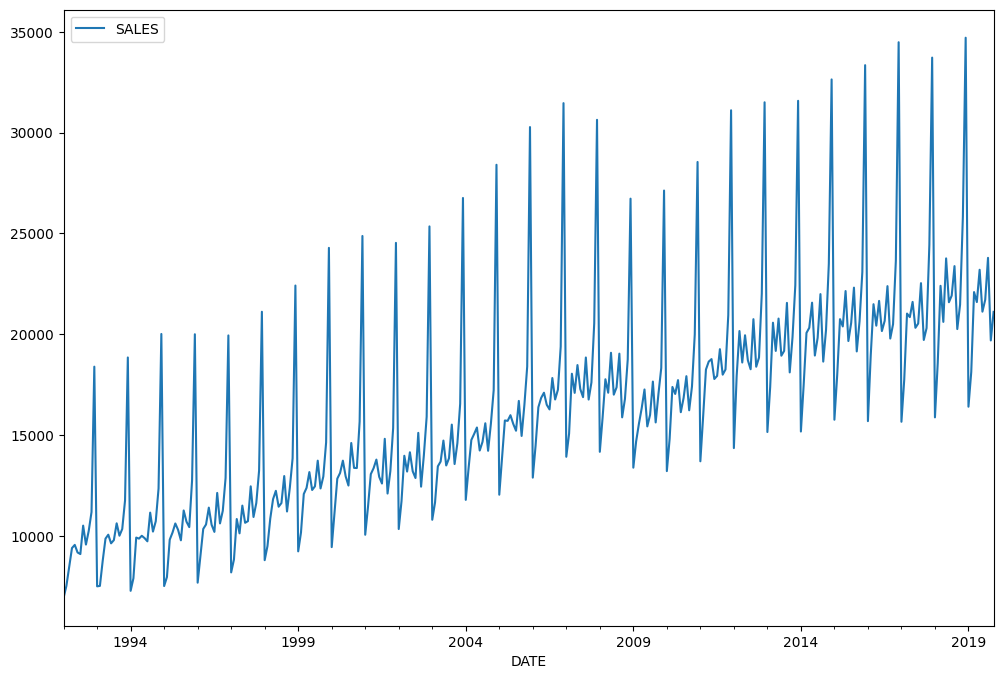

In [6]:
df.plot(figsize=(12, 8))

In [7]:
len(df), len(df) - 18 #

(334, 316)

In [8]:
test_size = 18
test_idx = len(df) - test_size

In [9]:
train = df.iloc[:test_idx]
test = df.iloc[test_idx:]
train, test

(            SALES
 DATE             
 1992-01-01   6938
 1992-02-01   7524
 1992-03-01   8475
 1992-04-01   9401
 1992-05-01   9558
 ...           ...
 2017-12-01  33720
 2018-01-01  15881
 2018-02-01  18585
 2018-03-01  22404
 2018-04-01  20616
 
 [316 rows x 1 columns],
             SALES
 DATE             
 2018-05-01  23764
 2018-06-01  21589
 2018-07-01  21919
 2018-08-01  23381
 2018-09-01  20260
 2018-10-01  21473
 2018-11-01  25831
 2018-12-01  34706
 2019-01-01  16410
 2019-02-01  18134
 2019-03-01  22093
 2019-04-01  21597
 2019-05-01  23200
 2019-06-01  21123
 2019-07-01  21714
 2019-08-01  23791
 2019-09-01  19695
 2019-10-01  21113)

In [10]:
#  Prerocessing
from sklearn.preprocessing import MinMaxScaler

In [11]:
scaler = MinMaxScaler()
scaler.fit(train)

MinMaxScaler()

In [12]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [13]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [14]:
len(test)

18

In [15]:
length = 12 # months batch
generator = TimeseriesGenerator(scaled_train, scaled_train, length=length, batch_size=1)
generator

In [16]:
X, y = generator[0]

In [17]:
X # checking for 12 months

array([[[0.        ],
        [0.02127505],
        [0.05580163],
        [0.08942056],
        [0.09512053],
        [0.08146965],
        [0.07860151],
        [0.12979233],
        [0.09566512],
        [0.1203892 ],
        [0.15426227],
        [0.41595266]]])

In [18]:
y # getting the 13th month

array([[0.02047633]])

In [19]:
scaled_train[:13] # from our scaled data, we got a good pred

array([[0.        ],
       [0.02127505],
       [0.05580163],
       [0.08942056],
       [0.09512053],
       [0.08146965],
       [0.07860151],
       [0.12979233],
       [0.09566512],
       [0.1203892 ],
       [0.15426227],
       [0.41595266],
       [0.02047633]])

In [20]:
# Creating model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

In [21]:
num_features = 1

In [22]:
model = Sequential()

# Add the Input layer explicitly
model.add(Input(shape=(length, num_features)))

# Add LSTM layer
model.add(LSTM(100, activation="relu"))

# Add Dense layer
model.add(Dense(1))

# Compile the model
model.compile(optimizer="adam", loss="mse")

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

In [26]:
validation_generator = TimeseriesGenerator(scaled_test, scaled_test, length=length, batch_size=1)

In [27]:
model.fit(generator, epochs=20, validation_data=validation_generator, callbacks=[early_stop])

Epoch 1/20
 77/304 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0590  

/Users/sabbha/Python-AI/TensorKeras/.tenv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0351 - val_loss: 0.0029
Epoch 2/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0186 - val_loss: 0.0576
Epoch 3/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0122 - val_loss: 0.0019
Epoch 4/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055 - val_loss: 0.0018
Epoch 5/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0025 - val_loss: 0.0032
Epoch 6/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - val_loss: 0.0029


In [28]:
losses = pd.DataFrame(model.history.history)

<Axes: >

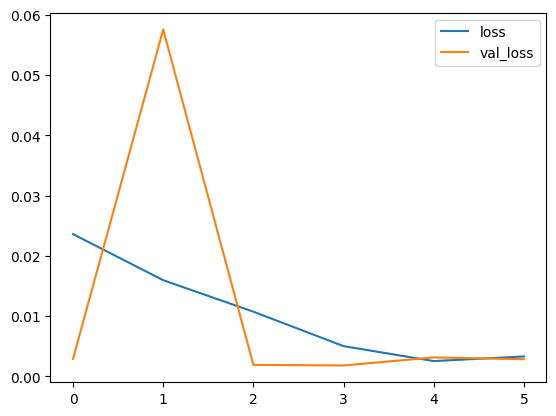

In [29]:
losses.plot()

In [30]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, num_features))

for i in range(len(test)):
    
    # get prediction 1 time stamp ahead ([0] is for grabbing just the number instead of [array])
    current_pred = model.predict(current_batch)[0]
    
    # store prediction
    test_predictions.append(current_pred) 
    
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [33]:
current_batch, current_batch.shape

(array([[[0.69275522],
         [1.13248765],
         [0.37105107],
         [0.45468903],
         [0.5990237 ],
         [0.53183663],
         [0.60288954],
         [0.55550259],
         [0.56997001],
         [0.65393394],
         [0.55123067],
         [0.58750379]]]),
 (1, 12, 1))

In [36]:
true_predictions = scaler.inverse_transform(test_predictions)

In [37]:
test['Predictions'] = true_predictions

/var/folders/1l/jh7lxvwd53g4g8kvvttg5mn00000gn/T/ipykernel_5468/4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


In [38]:
test

,SALES,Predictions
DATE,,
2018-05-01,23764,22415.796658
2018-06-01,21589,21118.084956
2018-07-01,21919,21412.260348
2018-08-01,23381,23543.173480
2018-09-01,20260,20718.005175
2018-10-01,21473,21476.149062
2018-11-01,25831,26019.249844
2018-12-01,34706,38131.239961
2019-01-01,16410,17158.230757


<Axes: xlabel='DATE'>

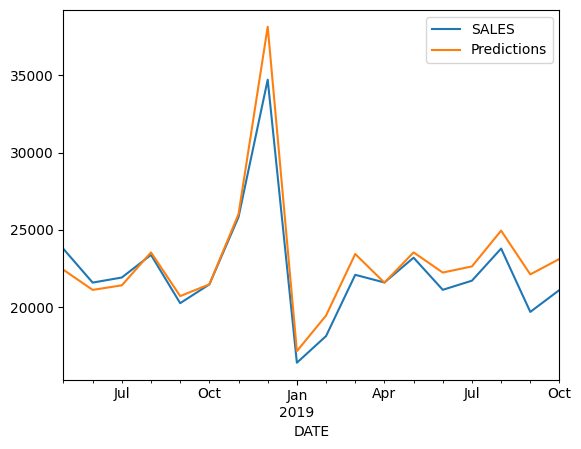

In [39]:
test.plot()